<img src="images/banner.png" style="width: 100%;">

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Hierarchical Clustering

*References*

[1] C. Aggarwal, Data Mining: The Textbook, Chapter 6.

[2] Han, Jiawei, Jian Pei, and Hanghang Tong. *Data mining: concepts and techniques 4th Edition.* Morgan kaufmann, 2023.

[3] B. Everitt, et. al. *Cluster Analysis 5th Edition*. John Wiley & Sons, 2011.

Adapted from notebooks of **Prof Christian Alis**, revised and edited by **Leodegario Lorenzo II**

Representative-based clustering methods are flat clustering methods. You tell them to cluster data points into $k$ clusters and they will assign a point into exactly one cluster. Hierarchical clustering methods, on the other hand, assign points to a branch of a tree. Instead of having a priori value of $k$, it can be set after analysis, depending on where in the tree (hierarchy) you want to be.

There are two main types of hierarchical clustering:
* **Agglomerative clustering**: bottom-up approach where smaller clusters are merged with nearby clusters
* **Divisive clustering**: top-down approach where clusters are successively partitioned into smaller clusters

In this notebook, we will demonstrate both clustering methods.

## 1 Data Loading and Preprocessing

For this demonstration, we will use the composition of various mammals' milk dataset from Hartigan (1975). We will perform standard scaling on this dataset to ensure no features dominate the distance computation.

In [2]:
with open('data/milk.txt') as f:
    content = f.readlines()
print(''.join(content[:25]))

#  file47.txt
#
#  Reference:
#
#    John Hartigan,
#    Clustering Algorithms,
#    Wiley, 1975.
#    ISBN 0-471-35645-X
#    LC: QA278.H36
#    Dewey: 519.5'3
#
#  A list of animals, and the constituents of their milk.
#  A shorter version of this table appears in file02.txt.
#
#  Name is the animal.
#
#  Water is the percentage of water.
#
#  Protein is the percentage of protein.
#
#  Fat is the percentage of fat.
#
#  Lactose is the percentage of lactose.
#
#  Ash is the percentage of ash.



In [3]:
data = pd.read_csv('data/milk.txt', skiprows=29, sep=r'\s+').set_index('Name')
data

,Water,Protein,Fat,Lactose,Ash
Name,,,,,
Horse,90.1,2.6,1.0,6.9,0.35
Orangutan,88.5,1.4,3.5,6.0,0.24
Monkey,88.4,2.2,2.7,6.4,0.18
Donkey,90.3,1.7,1.4,6.2,0.40
Hippo,90.4,0.6,4.5,4.4,0.10
Camel,87.7,3.5,3.4,4.8,0.71
Bison,86.9,4.8,1.7,5.7,0.90
Buffalo,82.1,5.9,7.9,4.7,0.78
Guinea Pig,81.9,7.4,7.2,2.7,0.85


### Standard Scaling

In [4]:
X = (data - data.mean()) / data.std()

In [5]:
X

,Water,Protein,Fat,Lactose,Ash
Name,,,,,
Horse,0.929636,-0.988899,-0.884959,1.511058,-1.011424
Orangutan,0.804811,-1.317437,-0.647272,1.019745,-1.243596
Monkey,0.797010,-1.098412,-0.723332,1.238106,-1.370235
Donkey,0.945240,-1.235302,-0.846929,1.128926,-0.905892
Hippo,0.953041,-1.536462,-0.552196,0.146302,-1.539088
Camel,0.742399,-0.742496,-0.656779,0.364663,-0.251590
Bison,0.679986,-0.386580,-0.818407,0.855975,0.149434
Buffalo,0.305510,-0.085420,-0.228941,0.310072,-0.103844
Guinea Pig,0.289907,0.325252,-0.295494,-0.781732,0.043902


In [6]:
X.shape

(25, 5)

### PCA

We won't perform principal component analysis on the dataset, but we will use the PCs to visualize the clustering result.

In [7]:
from sklearn.decomposition import PCA

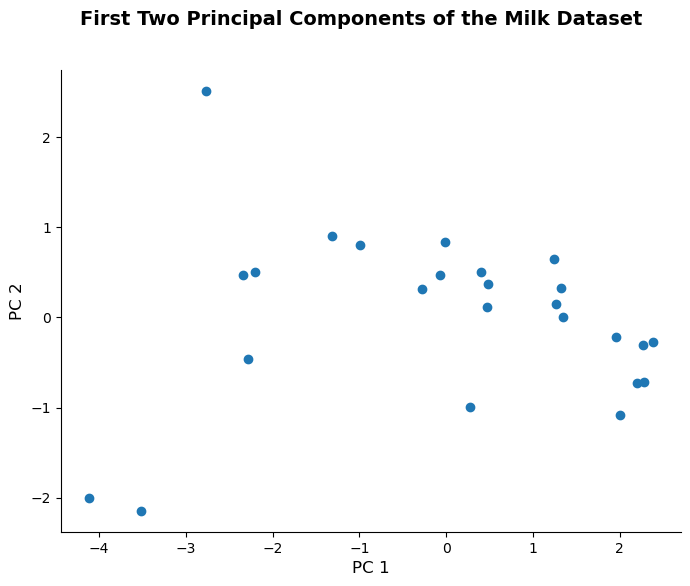

In [8]:
pca = PCA(n_components=2, random_state=1337)
X_truncated = pd.DataFrame(
    pca.fit_transform(X),
    columns=['PC 1', 'PC 2'])
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_truncated['PC 1'], X_truncated['PC 2'])
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('PC 1', fontsize=12)
ax.set_ylabel('PC 2', fontsize=12)
fig.suptitle("First Two Principal Components of the Milk Dataset", fontsize=14,
             weight='bold');

In [9]:
from utils import plot_principal_components

In [10]:
W = pd.DataFrame(pca.components_, index=['PC 1', 'PC 2'], columns=data.columns)

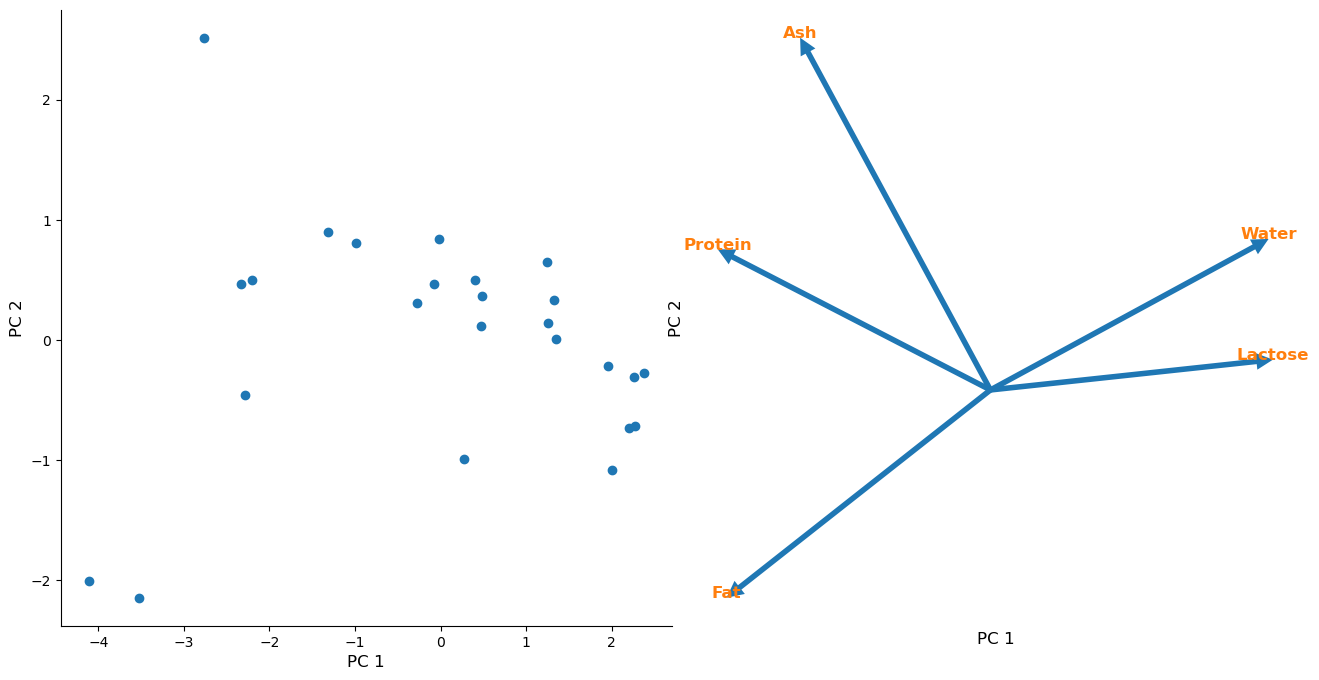

In [11]:
plot_principal_components(X_truncated, W, 'PC 1', 'PC 2');

## 2 Agglomerative Clustering

This is the generic agglomerative clustering algorithm:

**Algorithm** *AgglomerativeClustering*(Database: $D$)  
**begin**  
$\quad$Initialize $n \times n$ distance metric $M$ using $D$;  
$\quad$Assign each $i \in D$ to its own cluster;  
$\quad$**repeat**  
$\quad$$\quad$Pick closest pair of clusters $i$ and $j$ using $M$;  
$\quad$$\quad$Merge clusters $i$ and $j$;  
$\quad$$\quad$Delete rows/columns $i$ and $j$ from $M$ and create a new row and column for newly merged cluster;  
$\quad$$\quad$Update the entries of new row and column of $M$;  
$\quad$**until** termination criterion;  
$\quad$**return** clustering;  
**end**

Different agglomerative clustering methods differ on how they compute the distance between clusters. The different cluster distance measures are:

* **Change in SSE**: increase in the sum-of-squared errors when the clusters are merged
* **Single linkage**: smallest distance between a point from one cluster to any point in the other cluster
* **Complete linkage**: farthest distance between a point from one cluster to any point in the other cluster
* **Group-average linkage**: average intercluster distance
* **Centroid**: distance between cluster centroids
* **Change in cluster variance**: increase in the objective function (cluster variance) when the clusters are merged

### Ward's Method

The first agglomerative method that we will study is Ward's method. This method defines the distance between two clusters, $A$ and $B$, as the amount the sum of squares will increase when we merge them:

$$
\Delta(A, B) = \sum_{i \in A \bigcup B} \|x_i - m_{A \bigcup B}\|^2 - \sum_{i \in A} \|x_i - m_A\|^2 - \sum_{i \in B} \|x_i - m_B\|^2
$$

where $m_j$ is the center of cluster $j$, and $n_j$ is the number of points in it. $\Delta$ is the merging cost of combining the clusters $A$ and $B$. Starting from individual points as a cluster, the method merges them while trying to minimize the growth of $\Delta$. Given two pairs of clusters whose centers are equally far apart, Ward’s method will prefer to merge the smaller ones. Note that $\Delta$ always increases when we merge clusters.

The agglomerative clustering methodology is implemented by [scipy.cluster.hierarchy](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html), which computes the linkage matrix and plots the dendrogram given the data matrix and agglomerative clustering method.

In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [13]:
Z_ward = linkage(X, method='ward', optimal_ordering=True)

In [17]:
X.iloc[int(Z_ward[0][0])]

Water     -0.958346
Protein    1.146597
Fat        0.892946
Lactose   -0.836322
Ash        1.204760
Name: Deer, dtype: float64

In [18]:
X.iloc[int(Z_ward[0][1])]

Water     -1.044164
Protein    1.228732
Fat        0.949991
Lactose   -0.890913
Ash        1.204760
Name: Reindeer, dtype: float64

In [14]:
Z_ward

array([[20.        , 21.        ,  0.14263566,  2.        ],
       [15.        , 10.        ,  0.30313744,  2.        ],
       [ 2.        ,  1.        ,  0.34283672,  2.        ],
       [ 5.        , 14.        ,  0.35369258,  2.        ],
       [11.        ,  6.        ,  0.35993814,  2.        ],
       [ 7.        , 26.        ,  0.40253204,  3.        ],
       [ 3.        , 12.        ,  0.42023026,  2.        ],
       [16.        , 19.        ,  0.6168635 ,  2.        ],
       [ 0.        , 27.        ,  0.67106419,  3.        ],
       [33.        , 31.        ,  0.7905986 ,  5.        ],
       [ 8.        , 13.        ,  0.79244994,  2.        ],
       [28.        , 29.        ,  0.79578092,  4.        ],
       [24.        , 23.        ,  1.10799086,  2.        ],
       [35.        ,  9.        ,  1.2998052 ,  3.        ],
       [25.        , 22.        ,  1.48507159,  3.        ],
       [30.        , 38.        ,  1.51342458,  6.        ],
       [ 4.        , 34.

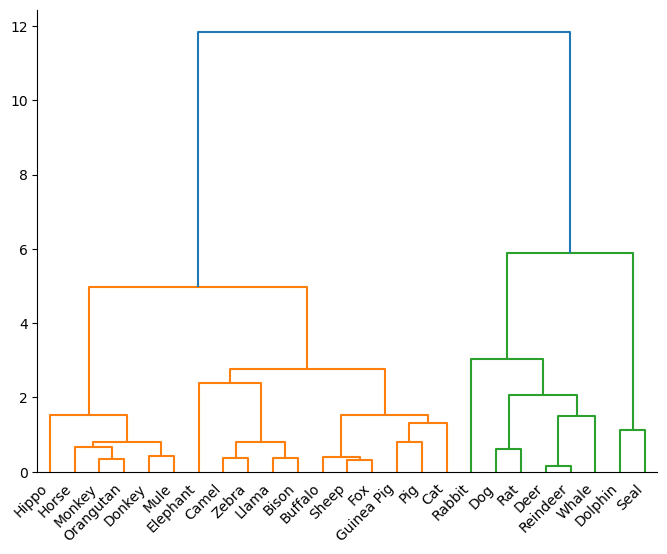

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

ward_dendrogram = dendrogram(Z_ward, ax=ax)
ax.set_xticklabels([data.index[int(label._text)]
                    for label in ax.get_xticklabels()], ha='right')
ax.spines[['top', 'right']].set_visible(False);

#### Choosing the Number of Partitions

To choose the number of groups or clusters, there are hierarchical clustering specific methods. First, is to consider looking at the fusion level $\alpha$, which denotes the distance at which two clusters are merged into a signle cluster, then deciding the *best cut* to be at the largest fusion level.

In [21]:
Z_ward

array([[20.        , 21.        ,  0.14263566,  2.        ],
       [15.        , 10.        ,  0.30313744,  2.        ],
       [ 2.        ,  1.        ,  0.34283672,  2.        ],
       [ 5.        , 14.        ,  0.35369258,  2.        ],
       [11.        ,  6.        ,  0.35993814,  2.        ],
       [ 7.        , 26.        ,  0.40253204,  3.        ],
       [ 3.        , 12.        ,  0.42023026,  2.        ],
       [16.        , 19.        ,  0.6168635 ,  2.        ],
       [ 0.        , 27.        ,  0.67106419,  3.        ],
       [33.        , 31.        ,  0.7905986 ,  5.        ],
       [ 8.        , 13.        ,  0.79244994,  2.        ],
       [28.        , 29.        ,  0.79578092,  4.        ],
       [24.        , 23.        ,  1.10799086,  2.        ],
       [35.        ,  9.        ,  1.2998052 ,  3.        ],
       [25.        , 22.        ,  1.48507159,  3.        ],
       [30.        , 38.        ,  1.51342458,  6.        ],
       [ 4.        , 34.

In [22]:
alpha = pd.Series(Z_ward[:, 2]) - pd.Series(Z_ward[:, 2]).shift(1).fillna(0)
alpha

0     0.142636
1     0.160502
2     0.039699
3     0.010856
4     0.006246
5     0.042594
6     0.017698
7     0.196633
8     0.054201
9     0.119534
10    0.001851
11    0.003331
12    0.312210
13    0.191814
14    0.185266
15    0.028353
16    0.013115
17    0.526014
18    0.332746
19    0.366121
20    0.292155
21    1.940901
22    0.907404
23    5.958051
dtype: float64

Some heuristics has been suggested to find this "largest change". In particular, Mojena (1977) suggested the *upper tail rule*, which selects the number of clusters corresponding to the first stage in the dendrogram that satisfies:

$$
\alpha_{j + 1} > \overline{\alpha} + ks_{\alpha}
$$

where $\alpha_0$, $\alpha_1$, ..., $\alpha_{n-1}$ are the fusion levels corresponding to stages with $n$, $n -1$, ..., 1 clusters.

In [23]:
alpha.expanding().mean()

0     0.142636
1     0.151569
2     0.114279
3     0.088423
4     0.071988
5     0.067089
6     0.060033
7     0.077108
8     0.074563
9     0.079060
10    0.072041
11    0.066315
12    0.085230
13    0.092843
14    0.099005
15    0.094589
16    0.089796
17    0.114031
18    0.125542
19    0.137571
20    0.144932
21    0.226567
22    0.256169
23    0.493747
dtype: float64

In [24]:
alpha.expanding().std()

0          NaN
1     0.012633
2     0.065203
3     0.074218
4     0.074040
5     0.067302
6     0.064211
7     0.076593
8     0.072052
9     0.069404
10    0.069837
11    0.069478
12    0.095268
13    0.095861
14    0.095407
15    0.093849
16    0.092992
17    0.136786
18    0.142086
19    0.148391
20    0.148515
21    0.409415
22    0.424447
23    1.235705
dtype: float64

In [25]:
alpha > alpha.expanding().mean() + 3.5*alpha.expanding().std()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21     True
22    False
23     True
dtype: bool

In [26]:
j = alpha.index[alpha > alpha.expanding().mean() + 3.5*alpha.expanding().std()]
j

Index([21, 23], dtype='int64')

Alternatively, we can plot $\alpha$ and $(\alpha_j - \overline{\alpha})/s_{\alpha}$ with respect to the number of clusters to aid in our decision making.

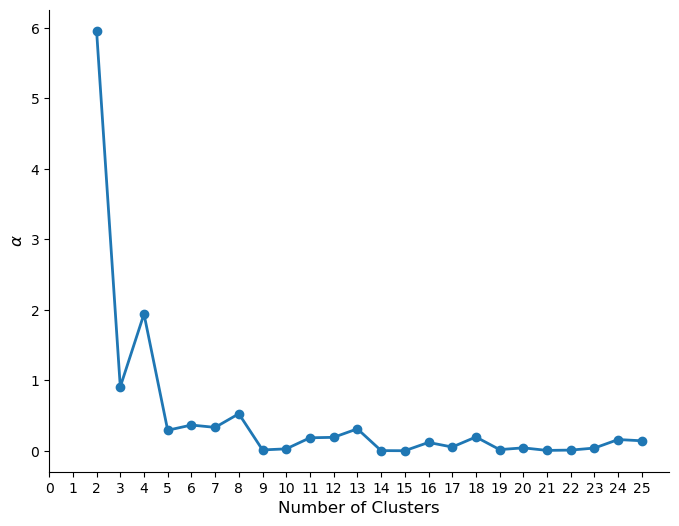

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(range(2, 26), alpha[::-1].to_numpy(), 'o-', lw=2)

ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(range(0, 26))
ax.set_xlabel("Number of Clusters", fontsize=12)
ax.set_ylabel(r"$\alpha$", fontsize=12);

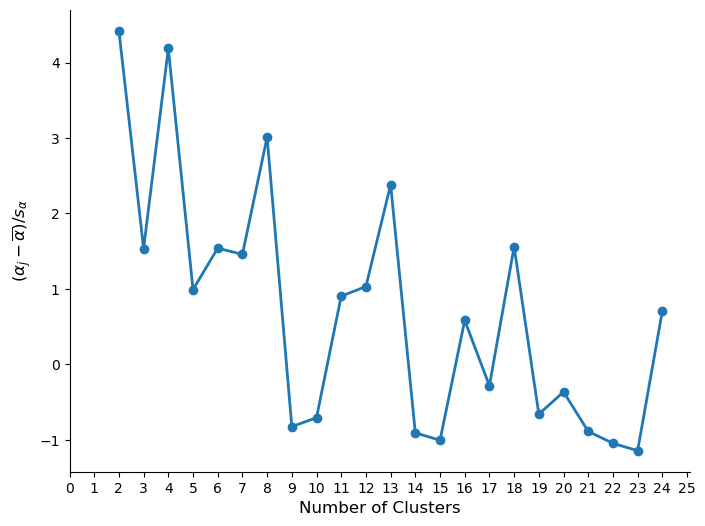

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    range(2, 26),
    ((alpha - alpha.expanding().mean()) / alpha.expanding().std())[::-1].to_numpy(),
    'o-', lw=2)

ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(range(0, 26))
ax.set_xlabel("Number of Clusters", fontsize=12)
ax.set_ylabel(r"$(\alpha_j - \overline{\alpha})/s_{\alpha}$", fontsize=12);

#### Plotting the Cluster Result

In [29]:
from scipy.cluster.hierarchy import cut_tree

In [30]:
j

Index([21, 23], dtype='int64')

In [31]:
Z_ward[j[0], 2]

np.float64(4.98447688378574)

To visualize the resulting clustering, we cut the three according to a certain condition, which can be a specified `height` of the dendrogram or the desired number of clusters `n_clusters`.

In [34]:
ward_labels = cut_tree(Z_ward, height=Z_ward[j[0], 2]).flatten()
ward_labels

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 2, 2, 2, 2,
       2, 3, 3])

In [35]:
from utils import plot_clustering

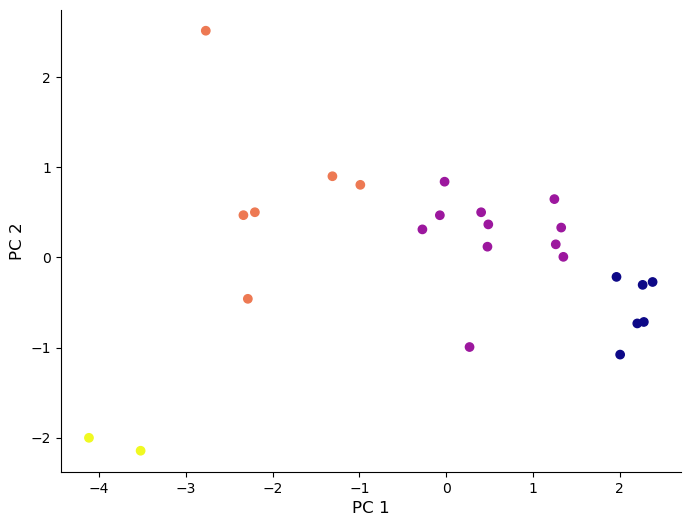

In [36]:
plot_clustering(X_truncated, 'PC 1', 'PC 2', ward_labels);

In [37]:
from utils import plot_cluster_averages

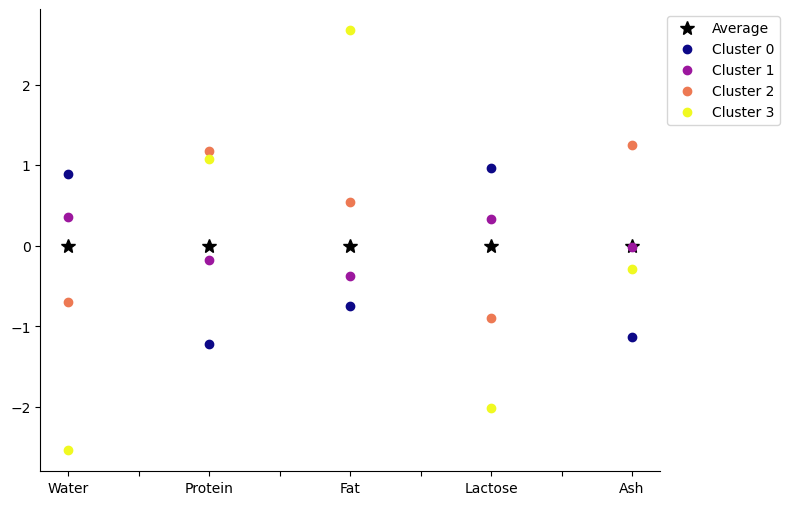

In [38]:
plot_cluster_averages(X, ward_labels);

In [39]:
for label in np.unique(ward_labels):
    print(f"Cluster {label}")
    print('\n'.join(X.index[ward_labels == label]))
    print("\n")

Cluster 0
Horse
Orangutan
Monkey
Donkey
Hippo
Mule


Cluster 1
Camel
Bison
Buffalo
Guinea Pig
Cat
Fox
Llama
Pig
Zebra
Sheep
Elephant


Cluster 2
Dog
Rabbit
Rat
Deer
Reindeer
Whale


Cluster 3
Seal
Dolphin




### Single Linkage

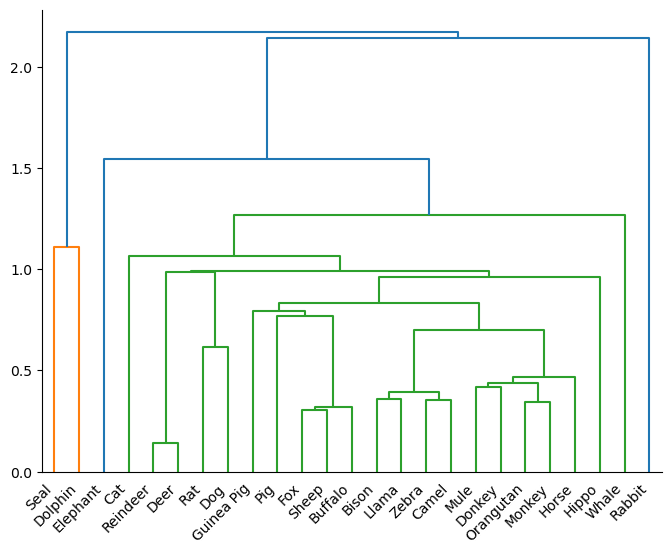

In [40]:
Z_sl = linkage(X, method='single', optimal_ordering=True)
fig, ax = plt.subplots(figsize=(8, 6))
sl_dendrogram = dendrogram(Z_sl, ax=ax)
ax.set_xticklabels([data.index[int(label._text)]
                    for label in ax.get_xticklabels()], ha='right')
ax.spines[['top', 'right']].set_visible(False);

In [41]:
sl_labels = cut_tree(Z_sl, n_clusters=4).flatten()

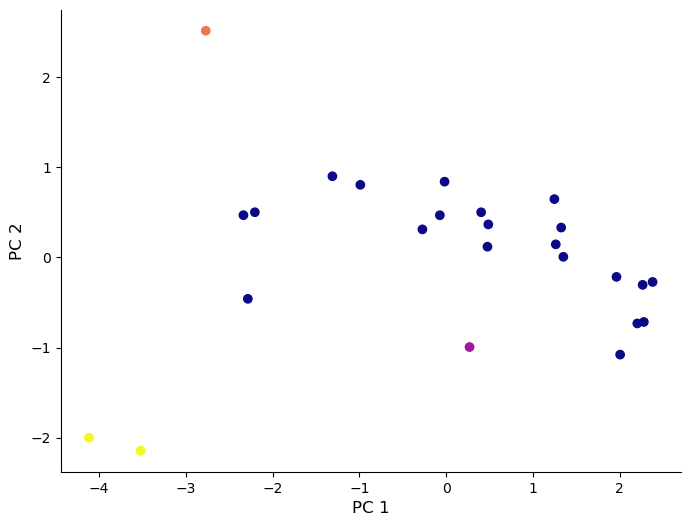

In [42]:
plot_clustering(X_truncated, 'PC 1', 'PC 2', sl_labels);

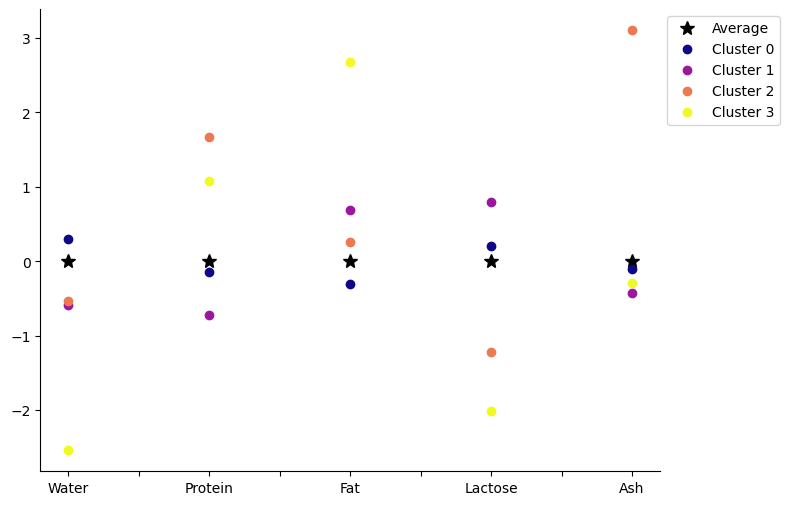

In [43]:
plot_cluster_averages(X, sl_labels);

### Comparing Dendrograms

In [44]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import cophenet

To compare two dendrograms as to whether which one preserves the original observed proximities better, a commonly used metric is the *cophenetic correlation*. Which computes the correlation between the cophenetic matrix elements $H$ and the original proximity matrix $D$.

The cophenetic matrix $H$ contains elements $h_{ij}$ which are the height at which the two objects in the dataset becomes members of the same cluster.

In [51]:
from scipy.spatial.distance import squareform

In [54]:
squareform(pdist(X)).shape

(25, 25)

In [60]:
cophenet(Z_ward, pdist(X))[0]

np.float64(0.7550432060549783)

In [61]:
cophenet(Z_sl, pdist(X))[0]

np.float64(0.7510936552477497)

In [62]:
pd.DataFrame([[cophenet(Z_ward, pdist(X))[0], cophenet(Z_sl, pdist(X))[0]]],
             index=['Cophenetic Correlation'], columns=['Ward', 'Single Linkage']).T

,Cophenetic Correlation
Ward,0.755043
Single Linkage,0.751094


## 3 Divisive Clustering

As opposed to Agglomerative clustering, divisive clustering starts by placing all data objects into one cluster, which is known as the *root cluster*, then divides the root cluster into several small subclusters.

A generic divisive clustering algorithm is demonstrated below:

**Algorithm** *DivisiveClustering*(Database: $D$, Clustering Algorithm $\mathcal{A}$)  
**begin**  
$\quad$Initialize tree $\mathcal{T}$ to root containing $D$;  

$\quad$**repeat**  
$\quad$$\quad$ Select a leaf node $L$ in $\mathcal{T}$ based on pre-defined criterion;  
$\quad$$\quad$ Use algorithm $\mathcal{A}$ to split $L$ into $L_1$, ..., $L_k$;  
$\quad$$\quad$ Add $L_1$, ..., $L_k$ as children of $L$ in $\mathcal{T}$; 

$\quad$**until** termination criterion;  
$\quad$**return** clustering;  
**end**

### Bisecting K-Means

If we choose algorithm $\mathcal{A}$ to be the k-Means algorithm, and choose to split each identified leaf node into 2 clusters, we perform the divisive clustering method known as ***Bisecting K-Means***.

This is implemented by sklearn thru the clustering object [`BisectingKMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.BisectingKMeans.html).

In [63]:
from sklearn.cluster import BisectingKMeans

In [64]:
bkm = BisectingKMeans(n_clusters=4, random_state=1337)
bkm.fit(X)
bkm_labels = bkm.predict(X)

In [65]:
bkm_labels

array([2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 2, 2, 3, 2, 3, 0, 2, 0, 0, 0, 0,
       1, 1, 1], dtype=int32)

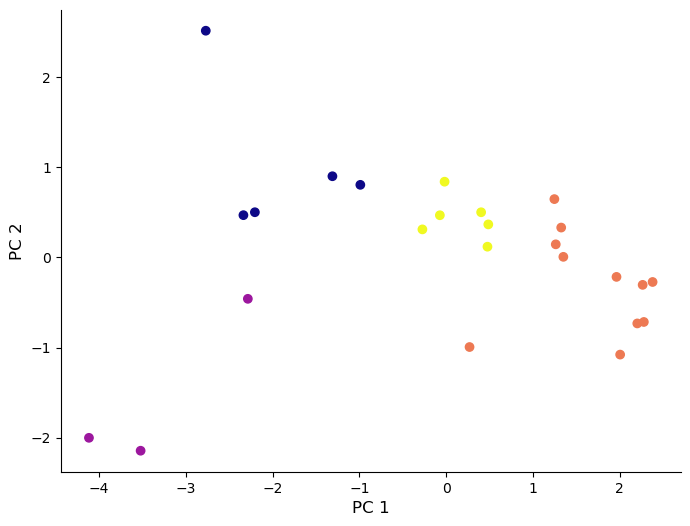

In [66]:
plot_clustering(X_truncated, 'PC 1', 'PC 2', bkm_labels);

#### Visualizing the Bisecting K-Means Method

To visualize how Bisecting K-Means performs its splitting, we can recursively fit the Bisecting K-Means object with different cluster settings.

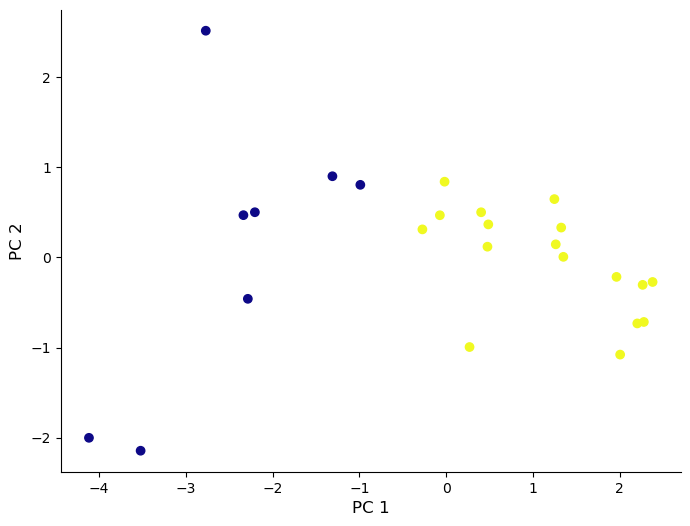

In [67]:
bkm = BisectingKMeans(n_clusters=2, random_state=1337)
bkm.fit(X)
bkm_labels = bkm.predict(X)
plot_clustering(X_truncated, 'PC 1', 'PC 2', bkm_labels);

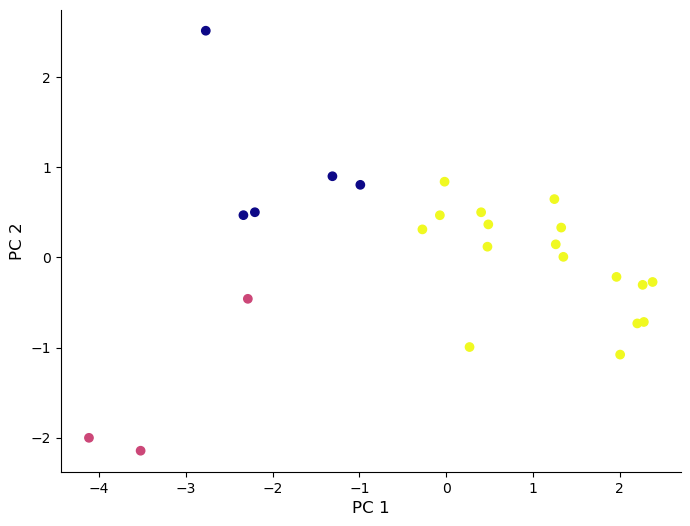

In [68]:
bkm = BisectingKMeans(n_clusters=3, random_state=1337)
bkm.fit(X)
bkm_labels = bkm.predict(X)
plot_clustering(X_truncated, 'PC 1', 'PC 2', bkm_labels);

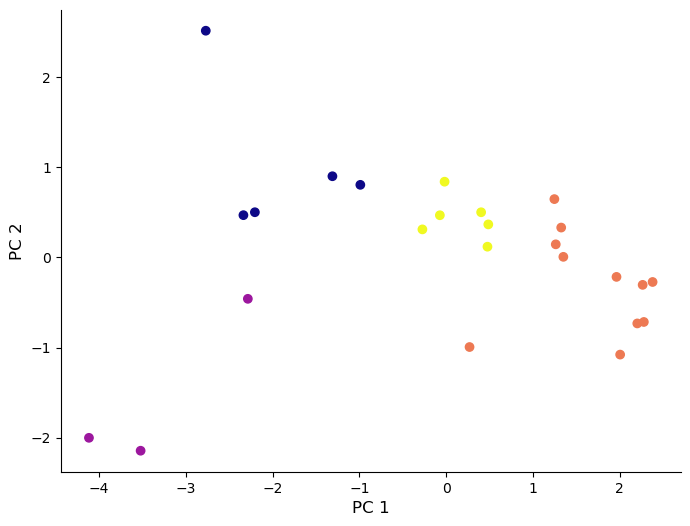

In [69]:
bkm = BisectingKMeans(n_clusters=4, random_state=1337)
bkm.fit(X)
bkm_labels = bkm.predict(X)
plot_clustering(X_truncated, 'PC 1', 'PC 2', bkm_labels);

Through this method, you can also construct the linkage matrix $Z$ by recording the distances between clusters for each split. This is left as an exercise.

## 4 Evaluation of Clusters

To compare the result of the three clustering methodology we've demonstrated here, we can use internal metrics such as those discussed in the previous notebook - *inertia* and *CH score*.

In [70]:
from sklearn.metrics import calinski_harabasz_score

In [71]:
inertia = {
    'Ward': X.groupby(ward_labels).apply(lambda x: (x - x.mean())**2).sum().sum(),
    'Bisecting K-Means': bkm.inertia_,
    'Single Linkage': X.groupby(sl_labels).apply(lambda x: (x - x.mean())**2).sum().sum()
}
ch_score = {
    'Ward': calinski_harabasz_score(X, ward_labels),
    'Bisecting K-Means': calinski_harabasz_score(X, bkm_labels),
    'Single Linkage': calinski_harabasz_score(X, sl_labels)
}
pd.DataFrame([inertia, ch_score], index=['Inertia', 'CH Score']).T

,Inertia,CH Score
Ward,20.009921,34.979176
Bisecting K-Means,21.887580,31.377929
Single Linkage,60.477762,6.889403


<img src="images/banner-down.png" style="width: 100%;">